# Matter power spectrum and line-of-sight sensitivity

Produces **`figs/matter_power.pdf`** (Fig. 8 of the paper), which puts **both**
benchmark campaigns on the same axes as the cosmological matter power spectrum.

The figure shows the dimensionless matter power spectrum
$\Delta^2_\delta(k) = k^3 P_\delta(k)/2\pi^2$ over 12 decades in comoving
wavenumber, together with the projected per-mode reach of the two astrometric
channels for the two lens systems:

- **Null hypothesis, pure CDM** --- linear spectrum with no cutoff, plus its
  nonlinear one-halo continuation (band bracketing the concentration--mass
  relations of Wang+2020 and Sanchez-Conde & Prada 2014), extending the
  `halofit` spectrum (Takahashi+2012) flatly to arbitrarily high $k$.
- **Fiducial 100 GeV thermal WIMP** --- free-streaming cutoff at
  $k_\mathrm{fs} \simeq 10^6\,\mathrm{Mpc}^{-1}$, its suppressed halo term, and the
  prompt cusps (Delos & White 2023) that repopulate the spectrum above it.
- **Projected sensitivity** --- the minimum detectable amplitude of a
  monochromatic clump population distributed along the line of sight at the mean
  cosmological density, in the stochastic (Eq. observable_1) and acceleration
  (Eq. observable_2) channels, for **both** systems: the galaxy lens B1422+231 at
  $\sigma_{\delta\theta} = 0.1\,\mu$as (solid) and the cluster lens
  SDSS J1029+2623 at $\sigma_{\delta\theta} = 1\,\mu$as (dashed). Both systems are
  configured through `make_system(...)` in the *Functions* section below, so the
  galaxy and cluster curves are computed by identical code.
- **Monochromatic clump overlay** --- thin curves showing the Poisson power of a
  clump population carrying a fraction $f_\mathrm{sub}$ of the matter, easing the
  read-across to `figs/SNR.pdf`.

**Inputs.** `Delta2_output.csv` and `Delta2_extended_output.csv`, the CLASS +
`halofit` spectra written by `Pnl.ipynb`. They are committed to the repository, so
this notebook runs without a CLASS installation.

*Runtime: ~1 minute.*

# Setup

## Packages

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.81, Om0=0.3099)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point
from lenstronomy.Util import util

In [2]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

## Parameters

In [3]:
import params_B1422_231 as pB
import params_J1029_2623 as pJ
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)   # cosmology used by both params modules

# fiducial ten-year campaign (both benchmark systems)
t_int = 10 * year
N_obs = 300

# --- galaxy lens: B1422+231, observed with EPIC (sigma_delta_theta = 0.1 muas) ---
# tangential eigenvalue of B^I for the brightest image of the bright A,B pair
# (macro_lens.ipynb), and the BULK fiducial |v_L| ~ 865 km/s (macro-magnified;
# the halo internal dispersion enters unmagnified -- kinematics fix; params_B1422_231).
eigvals_B1422 = np.load('macro_lens_results.npz')['eigvals_fit']
B_gal     = np.max(np.abs(eigvals_B1422[1]))   # image B, tangential |B| ~ 10.2
v_gal     = np.linalg.norm(pB.v_lens_fid)      # ~ 865 km/s (bulk)
sigma_gal = 0.1 * muas                         # EPIC-class relative astrometry

# --- cluster lens: SDSS J1029+2623, at sigma_delta_theta = 1 muas ---
# Acebron+2022 macro-model; EFFECTIVE fiducial |v_L| ~ 552 km/s (macro-magnified):
# bulk 474 km/s (+) the moving-clump member-halo term sqrt(2)*f_gal*sigma_v; the
# microhalos' own dispersion enters unmagnified -- see params_J1029_2623.
B_clu     = np.max(np.abs(pJ.eigvals_fit[2]))  # bright image C, tangential |B| ~ 22.6
v_clu     = np.linalg.norm(pJ.v_lens_fid)      # ~ 552 km/s (effective)
sigma_clu = 1.0 * muas                         # conservative light-centroiding precision

# strong-lensing boundary: the two systems' critical surface densities agree to 2%
# (galaxy 2.07e3 vs cluster 2.03e3 M_Solar/pc^2), so a single band is drawn.
Sigma_crit_gal = Sigma_crit(pB.d_lens, pB.d_source, pB.d_lens_source)
Sigma_crit_clu = Sigma_crit(pJ.d_lens, pJ.d_source, pJ.d_lens_source)
Sigma_crit_val = Sigma_crit_gal
print('Sigma_crit = %.4g (galaxy), %.4g (cluster) M_Solar/pc^2'
      % (Sigma_crit_gal/(M_Solar/pc**2), Sigma_crit_clu/(M_Solar/pc**2)))

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.040 muas = 0.195e-12 rad
theta_E_star =  1.400 muas
Sigma_crit = 2072 (galaxy), 2028 (cluster) M_Solar/pc^2


## Import Data

In [4]:
data = np.loadtxt("Delta2_output.csv", delimiter=",", skiprows=1)  # skip header
kk, k_h, D2_lin, D2_nl = data.T

data = np.loadtxt("Delta2_extended_output.csv", delimiter=",", skiprows=1)  # skip header
kk_ext, k_h_ext, D2_lin_ext, D2_nl_ext, D2_nl_30 = data.T

# Sensitivity

## Functions

In [5]:
def make_system(params, B, v_lens, sigma_delta_theta, label, ls, R=1):
    """Bundle everything the per-mode sensitivity needs for one lens + instrument configuration.
       The line-of-sight grid runs from the observer to that system's source redshift."""
    vec_a = np.logspace(np.log10(0.999), np.log10(1/(1 + params.z_source)), int(1e4))
    vec_z = 1 / vec_a - 1
    vec_D = cosmo.angular_diameter_distance(vec_z).value * Mpc * (1 + vec_z)  # comoving distance
    # sweep rate: bulk magnified by B, internal subhalo motion UNMAGNIFIED (kinematics fix)
    mu_tilde = np.sqrt((B * v_lens / params.D_lens)**2 + params.mu_int_drift**2)  # image-vs-subhalo sweep
    return dict(label=label, ls=ls, B=B, R=R, v_lens=v_lens, mu_tilde=mu_tilde,
                D_lens=params.D_lens, D_source=params.D_source,
                sigma_delta_theta=sigma_delta_theta, vec_a=vec_a, vec_D=vec_D)

sys_gal = make_system(pB, B_gal, v_gal, sigma_gal, r'B1422+231 (galaxy) + EPIC, 0.1 muas', 'solid')
# post-subtraction stellar microlensing residual for the acceleration channel
# (Sec. III C; sensitivity.ipynb / impact_numbers.py): worst-case unfitted star +
# fitted-star residual, rescaled to N=300, tau=10yr; image-A budget adopted per image,
# doubled for the differential pair.
sys_gal['sigma2_acc_star'] = 2 * 1.29e-5 * muasyy**2   # available, but NOT applied in this figure (all curves instrument-limited)
sys_clu = make_system(pJ, B_clu, v_clu, sigma_clu, r'SDSS J1029+2623 (cluster), 1 muas', (0,(5,2)))
systems = [sys_gal, sys_clu]

for s in systems:
    # fit uncertainties on the proper motion and acceleration (Eqs. noise_1, noise_2)
    s['sigma_mu_fit']  = 2*np.sqrt(3)  * s['sigma_delta_theta'] / np.sqrt(N_obs * t_int**2)
    s['sigma_acc_fit'] = 12*np.sqrt(5) * s['sigma_delta_theta'] / np.sqrt(N_obs * t_int**4)
    print('%-36s B = %5.2f, |v_L| = %4.0f km/s, mu_tilde = %.2f muas/yr, sigma = %.1f muas'
          % (s['label'], s['B'], s['v_lens']/(km/second), s['mu_tilde']/muasy,
             s['sigma_delta_theta']/muas))
    print('%-36s sigma_mu_fit = %.2g muas/yr, sigma_acc_fit = %.2g muas/yr^2'
          % ('', s['sigma_mu_fit']/muasy, s['sigma_acc_fit']/muasyy))

B1422+231 (galaxy) + EPIC, 0.1 muas  B = 10.19, |v_L| =  865 km/s, mu_tilde = 1.39 muas/yr, sigma = 0.1 muas
                                     sigma_mu_fit = 0.002 muas/yr, sigma_acc_fit = 0.0015 muas/yr^2
SDSS J1029+2623 (cluster), 1 muas    B = 22.62, |v_L| =  552 km/s, mu_tilde = 1.22 muas/yr, sigma = 1.0 muas
                                     sigma_mu_fit = 0.02 muas/yr, sigma_acc_fit = 0.015 muas/yr^2


### Prediction

In [6]:
def R_halo_pred(M_halo, rho_halo):
    """Predict the halo size (R_halo) given the halo mass (M_halo) and halo density (rho_halo)."""
    return (M_halo / rho_halo)**(1/3) / np.sqrt(2*np.pi)

print('R_halo_pred = {:.3g} pc'.format(R_halo_pred(2e-3 * M_Solar, 1e-1 * M_Solar / pc**3) / pc))

R_halo_pred = 0.108 pc


In [7]:
def Delta2_halo_pred(k, M_halo, rho_halo = 1e-1 * M_Solar / pc**3, f_halo = 1.0):
    R_halo = R_halo_pred(M_halo, rho_halo)
    rho_m = cosmo.Om0 * 3 * m_Planck**2 * (cosmo.h * 100 * km / second / Mpc)**2 
    prefac = (k**3 / (2*np.pi**2)) * f_halo * M_halo / rho_m 
    suppression = np.exp(- (k * R_halo)**2)
    return prefac * suppression

### Strong lensing regime

In [8]:
def Delta2_strong_lens(k_c):
    rho_m = cosmo.Om0 * 3 * m_Planck**2 * (cosmo.h * 100 * km / second / Mpc)**2 
    return 2 / (3*np.pi) * Sigma_crit_val / (rho_m / k_c)

### Power spectral density

In [9]:
def I_lm(omega, mu_tilde, D, k_c, Delta_c):
    k_tilde = omega / (mu_tilde * D)
    x = k_tilde / k_c
    result = np.zeros_like(x, dtype=float)
    mask = (x <= 1)
    result[mask] = (
        3 * np.pi * Delta_c / k_c**3
        * (np.arccos(np.clip(x[mask], -1, 1)) + x[mask] * np.sqrt(1 - x[mask]**2))
    )
    return result

In [10]:
def C_pq(omega, sys, k_c, Delta_c):
    """Stochastic astrometric PSD for a locally scale-invariant spectrum of amplitude Delta_c
       cut off at k_c, for the lens/instrument configuration `sys` (see make_system)."""
    prefac = sys['B']**2 * sys['R']**2 * 4 / omega
    integrand = ((1 - sys['vec_D']/sys['D_source'])**2
                 * I_lm(omega, sys['mu_tilde'], sys['vec_D'], k_c, Delta_c)
                 * (4 * np.pi * G_N * rho_M_0 / sys['vec_a'])**2  # rho_bar(z) a^2 = rho_m,0 (1+z)
    )
    integral = np.trapezoid(integrand, sys['vec_D'])
    return prefac * integral

def C_pq_vectorized(vec_omega, sys, k_c, Delta_c):
    return np.asarray([C_pq(w, sys, k_c, Delta_c) for w in np.atleast_1d(vec_omega)])

### Proper motion and acceleration functions

In [11]:
def smear_fac_mu(a):
    return np.heaviside(-a + 1e-2,1) + np.heaviside(a - 1e-2,0) * 144 * (a * np.cos(a/2) - 2 * np.sin(a/2))**2 / a**6
def smear_fac_acc(a):
    return np.heaviside(-a + 1e-2,1) + np.heaviside(a - 1e-2,0) * 14400 * (6 * a * np.cos(a/2) + (-12 + a**2) * np.sin(a/2))**2 / a**10

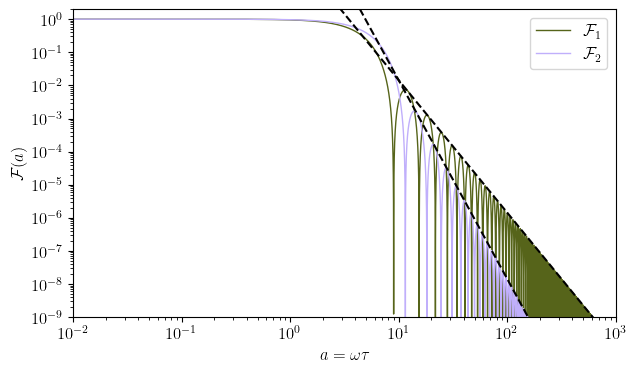

In [12]:
fig,ax = plt.subplots(1,1,figsize=(7,4))
x = np.logspace(-2,3,int(1e5))
ax.plot(x, smear_fac_mu(x), label=r'$\mathcal{F}_1$', color=colors[0], lw=1)
ax.plot(x, smear_fac_acc(x), label=r'$\mathcal{F}_2$', color=colors[1], lw=1)
ax.plot(x,144 * x**-4,'--k')
ax.plot(x,14400 * x**-6,'--k')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a = \omega \tau$')
ax.set_ylabel(r'$\mathcal{F}(a)$')
ax.set_xlim(1e-2, 1e3)
ax.set_ylim(1e-9, 2)
ax.legend(loc='upper right', fontsize=12);

In [13]:
def sigma2_acc_signal(tau, sys, k_c, Delta_c):
    omega_ref = 2 * np.pi / t_int
    vec_omega = omega_ref * np.logspace(-8,2,2000)
    vec_C = C_pq_vectorized(vec_omega, sys, k_c=k_c, Delta_c=Delta_c)
    integrand = (2*np.pi)**(-1) * vec_C * vec_omega**4 * smear_fac_acc(vec_omega * tau)
    integral = np.trapezoid(integrand, vec_omega)
    return integral

In [14]:
%timeit sigma2_acc_signal(tau=t_int, sys=sys_gal, k_c=1e8*Mpc**-1, Delta_c=1)

166 ms ± 3.04 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Power spectral density

In [15]:
# minimum detectable Delta_c in the stochastic channel: the signal PSD at the lowest
# observable frequency omega_min = 2 pi / tau must exceed the instrumental noise PSD.
omega_min = 2 * np.pi / t_int
vec_k_c_stoch = np.logspace(5,10,int(1e4)) * Mpc**-1

for s in systems:
    C_noise = C_EPIC(omega=1.001*omega_min, t_int=t_int, N_obs=N_obs,
                     sigma_delta_theta=s['sigma_delta_theta'])
    Delta_c_stoch = np.full(len(vec_k_c_stoch), np.nan)
    for i, k_c in enumerate(vec_k_c_stoch):
        C_signal = C_pq(omega=omega_min, sys=s, k_c=k_c, Delta_c=1)
        if C_signal > 0:
            Delta_c_stoch[i] = C_noise / C_signal
    s['Delta_c_stoch'] = Delta_c_stoch
    i_min = int(np.nanargmin(Delta_c_stoch))
    print('%-36s stoch. min Delta^2 = %.3g at k = %.3g h/Mpc'
          % (s['label'], Delta_c_stoch[i_min], vec_k_c_stoch[i_min]/(cosmo.h*Mpc**-1)))

B1422+231 (galaxy) + EPIC, 0.1 muas  stoch. min Delta^2 = 2.06e+04 at k = 3.63e+07 h/Mpc


SDSS J1029+2623 (cluster), 1 muas    stoch. min Delta^2 = 2.41e+06 at k = 5.4e+07 h/Mpc


## Proper Motion and Acceleration

In [16]:
# minimum detectable Delta_c in the acceleration channel: the variance of the stochastic
# contribution to the fitted differential acceleration must exceed the fit uncertainty.
vec_k_c_acc = np.logspace(-1,10,int(120)) * Mpc**-1

for s in systems:
    # ALL curves in this figure are instrument-limited, for a fair channel comparison:
    # the stellar residual is a smooth, near-quadratic trend that would burden only the
    # acceleration channel (see s['sigma2_acc_star'], plotted elsewhere), not the stochastic one.
    sigma2_acc_noise = 720 * s['sigma_delta_theta']**2 / (t_int**4 * N_obs)
    Delta_c_acc = np.zeros_like(vec_k_c_acc, dtype=float)
    for i, k_c in enumerate(vec_k_c_acc):
        sigma2_acc_signal_1 = sigma2_acc_signal(tau=t_int, sys=s, k_c=k_c, Delta_c=1)
        if sigma2_acc_signal_1 > 0:
            Delta_c_acc[i] = sigma2_acc_noise / sigma2_acc_signal_1
    s['Delta_c_acc'] = Delta_c_acc
    i_min = int(np.argmin(np.where(Delta_c_acc > 0, Delta_c_acc, np.inf)))
    print('%-36s sigma_acc_noise = %.2g muas/yr^2, acc. min Delta^2 = %.3g at k = %.3g h/Mpc'
          % (s['label'], np.sqrt(sigma2_acc_noise)/muasyy,
             Delta_c_acc[i_min], vec_k_c_acc[i_min]/(cosmo.h*Mpc**-1)))

B1422+231 (galaxy) + EPIC, 0.1 muas  sigma_acc_noise = 0.0015 muas/yr^2, acc. min Delta^2 = 3.17e+04 at k = 2.41e+07 h/Mpc


SDSS J1029+2623 (cluster), 1 muas    sigma_acc_noise = 0.015 muas/yr^2, acc. min Delta^2 = 3.64e+06 at k = 2.98e+07 h/Mpc


## Non-linear matter power spectrum (CDM)

Fiducial estimate of the small-scale non-linear matter power spectrum within standard cold dark matter:
1. a Press--Schechter / halo-model one-halo term (Sheth--Tormen mass function, NFW profiles), shown as a band spanning the halo concentration--mass relation from the (pessimistic) universal relation of Wang et al. 2020 to the (more optimistic) flattened relation of Sanchez-Conde & Prada 2014, and
2. prompt cusps (Delos & White 2023).


In [17]:
# --- background densities (natural units) ---
rho_m_0    = cosmo.Om0 * 3 * m_Planck**2 * (cosmo.h * 100 * km / second / Mpc)**2   # mean matter density today
rho_crit_0 = rho_m_0 / cosmo.Om0
delta_c    = 1.686                                                                  # spherical-collapse threshold

# --- fiducial dark-matter free-streaming cutoff ---
# thermal WIMP with m_chi = 100 GeV, T_kd = 30 MeV  ->  k_fs ~ 1.06e6 / Mpc  (Delos & White 2023)
k_fs = 1.06e6 * Mpc**-1
M_fs = (4 * np.pi / 3) * rho_m_0 * (np.pi / k_fs)**3                                # free-streaming mass
print('M_fs = %.2e M_sun   (k_fs = %.2e / Mpc)' % (M_fs / M_Solar, k_fs * Mpc))

# --- linear dimensionless power spectrum (extended CDM, optional free-streaming cutoff) ---
_int_lnD2lin = interp1d(np.log(kk_ext), np.log(D2_lin_ext), bounds_error=False,
                        fill_value=(np.log(D2_lin_ext[0]), np.log(D2_lin_ext[-1])))
def Delta2_lin(k, cutoff=True):
    """Linear Delta^2(k); k in natural units. Free-streaming cutoff multiplies the power by exp[-2 (k/k_fs)^2]."""
    out = np.exp(_int_lnD2lin(np.log(k * Mpc)))
    return out * np.exp(-2 * (k / k_fs)**2) if cutoff else out

# --- variance on a mass scale M (real-space top-hat) ---
def _W_tophat(x):
    x = np.asarray(x, float); w = np.ones_like(x); g = x > 1e-3; xx = x[g]
    w[g] = 3 * (np.sin(xx) - xx * np.cos(xx)) / xx**3
    return w
def R_lagrangian(M):
    return (3 * M / (4 * np.pi * rho_m_0))**(1 / 3)                                 # comoving Lagrangian radius
def sigma_of_M(M, cutoff=True):
    R = R_lagrangian(M)
    integrand = lambda lk: Delta2_lin(np.exp(lk) * Mpc**-1, cutoff) * _W_tophat(np.exp(lk) * Mpc**-1 * R)**2
    return np.sqrt(quad(integrand, np.log(1e-4), np.log(1e11), limit=400)[0])

# tabulate sigma(M) and its logarithmic derivative, with (WIMP) and without (pure CDM) the cutoff
vec_M_sig = np.logspace(-14, 16, 150) * M_Solar
_int_lnsig = {}
for _cut in (True, False):
    _vec_sigma = np.array([sigma_of_M(M, cutoff=_cut) for M in vec_M_sig])
    _int_lnsig[_cut] = interp1d(np.log(vec_M_sig), np.log(_vec_sigma), fill_value='extrapolate')
def sigma_M(M, cutoff=True):  return np.exp(_int_lnsig[cutoff](np.log(M)))
def dlnsigma_dlnM(M, cutoff=True):
    h = 1e-3
    return (np.log(sigma_M(M * np.exp(h), cutoff)) - np.log(sigma_M(M * np.exp(-h), cutoff))) / (2 * h)

# --- linear growth factor D(a) and collapse redshift z_coll(M), where sigma(M) D(a_coll) = delta_c ---
def _growth_unnorm(a):
    Om, OL = cosmo.Om0, 1 - cosmo.Om0
    return 2.5 * Om * np.sqrt(Om / a**3 + OL) * quad(lambda ap: (Om / ap**3 + OL)**-1.5 / ap**3, 1e-8, a)[0]
_D_norm = _growth_unnorm(1.0)
_a_grid = np.logspace(-4, 0, 400); _D_grid = np.array([_growth_unnorm(a) / _D_norm for a in _a_grid])
_int_a_of_D = interp1d(_D_grid, _a_grid, bounds_error=False, fill_value=(_a_grid[0], _a_grid[-1]))
def z_collapse(M, cutoff=True):
    D = delta_c / sigma_M(M, cutoff)
    return 1 / float(_int_a_of_D(D)) - 1 if D < 1 else 0.0
_int_zc = {}
for _cut in (True, False):
    _vec_zc = np.array([z_collapse(M, _cut) for M in vec_M_sig])
    _int_zc[_cut] = interp1d(np.log(vec_M_sig), _vec_zc, bounds_error=False,
                             fill_value=(_vec_zc[0], _vec_zc[-1]))
def z_coll_M(M, cutoff=True): return float(_int_zc[cutoff](np.log(M)))

# --- Sheth-Tormen halo mass function dn/dlnM ---
def dn_dlnM(M, cutoff=True):
    nu = delta_c / sigma_M(M, cutoff)
    A_ST, a_ST, p_ST = 0.3222, 0.707, 0.3
    nu_p = np.sqrt(a_ST) * nu
    f_nu = A_ST * np.sqrt(2 / np.pi) * nu_p * np.exp(-nu_p**2 / 2) * (1 + nu_p**(-2 * p_ST))
    return (rho_m_0 / M) * f_nu * abs(dlnsigma_dlnM(M, cutoff))

print('M = 1e-6 Msun:  sigma = %.2f (WIMP) | %.2f (pure CDM), z_coll = %.1f | %.1f'
      % (sigma_M(1e-6 * M_Solar), sigma_M(1e-6 * M_Solar, cutoff=False),
         z_coll_M(1e-6 * M_Solar), z_coll_M(1e-6 * M_Solar, cutoff=False)))
print('M = 1e+0 Msun:  sigma = %.2f, z_coll = %.1f' % (sigma_M(1e0  * M_Solar), z_coll_M(1e0  * M_Solar)))

M_fs = 4.46e-06 M_sun   (k_fs = 1.06e+06 / Mpc)


/var/folders/4c/r0fv34l54990y0356vhxlw7c0000gn/T/ipykernel_2965/893497744.py:30: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return np.sqrt(quad(integrand, np.log(1e-4), np.log(1e11), limit=400)[0])


M = 1e-6 Msun:  sigma = 15.01 (WIMP) | 15.38 (pure CDM), z_coll = 10.4 | 10.7
M = 1e+0 Msun:  sigma = 12.44, z_coll = 8.5


In [18]:
# --- one-halo (Press-Schechter / halo-model) non-linear power spectrum with NFW profiles ---
# concentration-mass relation: extrapolations to substellar masses differ widely, so the
# prediction is bracketed by two published relations:
#   lower edge: Wang et al. 2020 universal (Einasto) relation -- the least concentrated
#   upper edge: Sanchez-Conde & Prada 2014 flattened relation -- roughly 2x higher c at M_fs
# WIMP variants are truncated near the free-streaming mass with the Wang et al. 2020
# suppression factor exp[-0.529 (M_fs/M)^(1/3)]; pure-CDM variants carry no cutoff.
def conc_Wang(M):
    return np.clip(c_Einasto(M, h=cosmo.h, M_fs=M_fs), 2, 200)
def conc_Wang_nocut(M):
    return np.clip(c_Einasto(M, h=cosmo.h), 2, 200)

_scp14_coeff = [37.5153, -1.5093, 1.636e-2, 3.66e-4, -2.89237e-5, 5.32e-7]
def _scp14_pol(M):
    x = np.log(M / (cosmo.h**-1 * M_Solar))
    return sum(ci * x**i for i, ci in enumerate(_scp14_coeff))
def conc_SCP14(M):
    """Sanchez-Conde & Prada 2014 (Eq. 1) c_200(M, z=0)."""
    return np.clip(np.exp(-0.529 * (M_fs / M)**(1/3)) * _scp14_pol(M), 2, 200)
def conc_SCP14_nocut(M):
    return np.clip(_scp14_pol(M), 2, 200)

def r_200(M):
    return (3 * M / (4 * np.pi * 200 * rho_crit_0))**(1 / 3)
def u_NFW(k, M, conc):
    """Normalized Fourier transform of an NFW halo of mass M (u -> 1 as k -> 0)."""
    c = conc(M); r_s = r_200(M) / c; x = k * r_s
    mc = np.log(1 + c) - c / (1 + c)
    si,  ci  = sp.special.sici(x)
    si1, ci1 = sp.special.sici((1 + c) * x)
    return (np.sin(x) * (si1 - si) + np.cos(x) * (ci1 - ci) - np.sin(c * x) / ((1 + c) * x)) / mc

_lnM_1h = np.log(np.logspace(-13, 16, 290) * M_Solar)
def Delta2_PS(k, conc=conc_Wang, cutoff=True):
    """Dimensionless one-halo non-linear matter power spectrum (Sheth-Tormen mass function x NFW profiles)."""
    k = np.atleast_1d(k).astype(float)
    integral = np.zeros_like(k); dlnM = _lnM_1h[1] - _lnM_1h[0]
    for lnM in _lnM_1h:
        M = np.exp(lnM)
        integral += dn_dlnM(M, cutoff) * M**2 * u_NFW(k, M, conc)**2 * dlnM
    return k**3 / (2 * np.pi**2) * integral / rho_m_0**2

for M in np.array([1e-6, 1e0, 1e6]) * M_Solar:
    print('M = %8.0e M_sun:  c_Wang = %5.1f (%5.1f no cut), c_SCP14 = %5.1f (%5.1f no cut)'
          % (M / M_Solar, conc_Wang(M), conc_Wang_nocut(M), conc_SCP14(M), conc_SCP14_nocut(M)))

M =    1e-06 M_sun:  c_Wang =  13.8 ( 33.0 no cut), c_SCP14 =  25.0 ( 59.7 no cut)
M =    1e+00 M_sun:  c_Wang =  27.0 ( 27.2 no cut), c_SCP14 =  37.7 ( 38.1 no cut)
M =    1e+06 M_sun:  c_Wang =  20.6 ( 20.6 no cut), c_SCP14 =  20.3 ( 20.3 no cut)


In [19]:
# --- prompt cusps (Delos & White 2023): rho = A r^{-3/2} between r_core and r_cusp ---
# Each density peak collapses promptly into a r^{-3/2} cusp; A and r_cusp follow from the peak.
z5_cusp    = 31.0       # redshift by which 5% of initial peaks have collapsed (fiducial WIMP)
f_surv     = 0.5        # fraction of cusps surviving hierarchical assembly
ratio_cusp = 500.0      # r_cusp / r_core for WIMP prompt cusps
r_cusp_med = 5e-3 * pc  # characteristic outer cusp radius (annihilation/power-weighted)

def _cusp_FT2(k, r_cusp, r_core):
    """ |rho_tilde(k)|^2 k^3 / (8 pi^3 A^2) for a truncated, cored r^{-3/2} cusp.
        -> 1 on the cusp plateau (1/r_cusp << k << 1/r_core); ~ (k r_cusp)^3 below; -> 0 above. """
    Sc, _ = sp.special.fresnel(np.sqrt(2 * k * r_cusp / np.pi))
    So, _ = sp.special.fresnel(np.sqrt(2 * k * r_core / np.pi))
    I_cusp = np.sqrt(2 * np.pi / k) * (Sc - So)                                    # int_{r_core}^{r_cusp} r^{-1/2} sin(kr) dr
    I_core = r_core**-1.5 * (np.sin(k * r_core) - k * r_core * np.cos(k * r_core)) / k**2
    return ((4 * np.pi / k) * (I_core + I_cusp))**2 * k**3 / (8 * np.pi**3)

def Delta2_cusp(k, z5=z5_cusp, ratio=ratio_cusp):
    """Dimensionless matter power spectrum contributed by prompt cusps.
       Plateau amplitude anchored to Delos & White 2023, Eq. (2.8): the cusps' mean
       squared density per unit mass is 160 f_surv (1+z5)^3 times the cosmic mean."""
    k = np.atleast_1d(k).astype(float)
    plateau = 160 * f_surv * (1 + z5)**3 / (0.531 + np.log(ratio))
    lnr = np.log(r_cusp_med) + np.linspace(-1.5, 1.5, 21) * 0.6                    # spread in cusp size
    w = np.exp(-((lnr - np.log(r_cusp_med)) / 0.6)**2 / 2); w /= w.sum()
    shape = np.zeros_like(k)
    for lr, wi in zip(lnr, w):
        shape += wi * _cusp_FT2(k, np.exp(lr), np.exp(lr) / ratio)
    return plateau * shape

print('prompt-cusp plateau:  Delta^2 = %.2g' % (160 * f_surv * (1 + z5_cusp)**3 / (0.531 + np.log(ratio_cusp))))

prompt-cusp plateau:  Delta^2 = 3.9e+05


In [20]:
# evaluate the linear and non-linear estimates on the extended wavenumber grid
k_nat_ext    = kk_ext * Mpc**-1
D2_lin_cut   = Delta2_lin(k_nat_ext, cutoff=True)         # linear, with WIMP free-streaming cutoff
# pure CDM (null hypothesis): no cutoff anywhere -- ever smaller halos keep contributing
D2_nl_CDM_lo = Delta2_PS(k_nat_ext, conc=conc_Wang_nocut,  cutoff=False)
D2_nl_CDM_hi = Delta2_PS(k_nat_ext, conc=conc_SCP14_nocut, cutoff=False)
# fiducial WIMP: free-streaming cutoff (mass function + concentrations) and prompt cusps
D2_nl_PS_lo  = Delta2_PS(k_nat_ext, conc=conc_Wang)       # halos, pessimistic concentrations (Wang et al. 2020)
D2_nl_PS_hi  = Delta2_PS(k_nat_ext, conc=conc_SCP14)      # halos, optimistic concentrations (Sanchez-Conde & Prada 2014)
D2_nl_cusp   = Delta2_cusp(k_nat_ext)                     # prompt cusps
D2_nl_tot_lo = D2_nl_PS_lo + D2_nl_cusp                   # total WIMP estimate (band edges)
D2_nl_tot_hi = D2_nl_PS_hi + D2_nl_cusp

# --- monochromatic clump population (the (M_L, rho_s) plane of Fig. SNR) ---
# A fraction f_sub of the matter bound in halos of a single mass M_L and scale density
# rho_L, in the profile convention of the paper (rho ~ exp[-r^2/2 r_L^2]/r with rho_L =
# rho(r_L), so M_L = 4 pi sqrt(e) rho_L r_L^3 and the form factor is Gaussian).  Their
# Poisson (shot-noise) contribution to the cosmic-mean spectrum is
#     Delta^2(k) = k^3 f_sub M_L |u(k)|^2 / (2 pi^2 rho_m,0),   |u(k)|^2 = exp[-(k r_L)^2],
# the same convention as los_vs_lens_decomposition.py.  It peaks at k = sqrt(3/2)/r_L with
# a height Delta^2_peak = 0.430 f_sub rho_L / rho_m,0 that depends only on f_sub and rho_L,
# not on M_L -- so the three curves below share a common peak and differ only in k.
# Sizes are treated as comoving (z = 0 population); multiply r_L by (1 + pB.z_lens) to place
# the clumps at the lens redshift instead (shifts the peak down by (1+z_L)^3 ~ 2.4).
def r_L_of_M(M_L, rho_L):
    return (M_L / (4 * np.pi * np.sqrt(np.e) * rho_L))**(1/3)

def Delta2_clump(k, M_L, rho_L=1 * M_Solar / pc**3, f_sub=0.1):
    r_L = r_L_of_M(M_L, rho_L)
    return k**3 * f_sub * M_L * np.exp(-(k * r_L)**2) / (2 * np.pi**2 * rho_m_0)

f_sub_clump   = 0.1                       # substructure fraction of the A,B image-pair convergence
rho_L_clump   = 1.0 * M_Solar / pc**3     # fiducial CDM scale density (y axis of Fig. SNR)
M_L_clumps    = np.array([1e0, 1e-3, 1e-6]) * M_Solar
lab_M_clumps  = [r'$1\,M_\odot$', r'$10^{-3}\,M_\odot$', r'$10^{-6}\,M_\odot$']
D2_clumps     = [Delta2_clump(k_nat_ext, M, rho_L_clump, f_sub_clump) for M in M_L_clumps]
for M, D2 in zip(M_L_clumps, D2_clumps):
    i = int(np.argmax(D2))
    print('clump M_L = %8.0e M_sun:  r_L = %8.3g pc,  peak Delta^2 = %.3g at k = %.3g h/Mpc'
          % (M / M_Solar, r_L_of_M(M, rho_L_clump) / pc, D2[i], k_h_ext[i]))


clump M_L =    1e+00 M_sun:  r_L =    0.364 pc,  peak Delta^2 = 1.05e+06 at k = 4.95e+06 h/Mpc
clump M_L =    1e-03 M_sun:  r_L =   0.0364 pc,  peak Delta^2 = 1.05e+06 at k = 4.97e+07 h/Mpc
clump M_L =    1e-06 M_sun:  r_L =  0.00364 pc,  peak Delta^2 = 1.05e+06 at k = 4.93e+08 h/Mpc


# Plot

In [21]:
colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

B1422+231 (galaxy) + EPIC, 0.1 muas  stoch: 2.06e+04 at k = 3.63e+07 h/Mpc | acc: 3.17e+04 at k = 2.41e+07 h/Mpc
SDSS J1029+2623 (cluster), 1 muas    stoch: 2.41e+06 at k = 5.4e+07 h/Mpc | acc: 3.64e+06 at k = 2.98e+07 h/Mpc


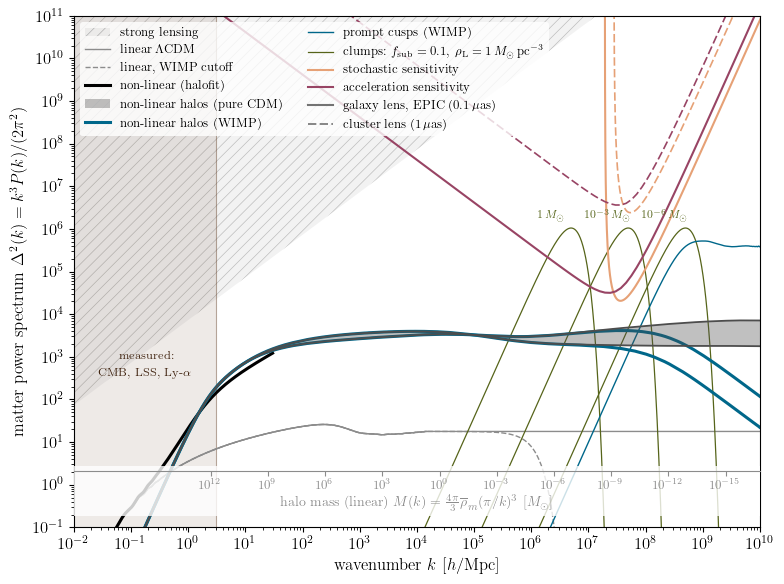

In [22]:
fig,ax = plt.subplots(1,1,figsize=(8,6))

xlim = (1e-2,1e10); ax.set_xlim(xlim);
ylim = (1e-1,1e11); ax.set_ylim(ylim);
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'wavenumber $k~[h/\mathrm{Mpc}]$');
ax.set_ylabel(r'matter power spectrum $\Delta^2(k) = k^3 P(k) / (2 \pi^2)$');
ax.set_xticks(np.logspace(np.log10(xlim[0]),np.log10(xlim[1]),1+int(np.log10(xlim[1]/xlim[0]))),minor=False);
ax.set_xticks(np.outer(np.logspace(np.log10(xlim[0]),np.log10(xlim[1])-1,int(np.log10(xlim[1]/xlim[0]))),range(1,10)).flatten(),minor=True);
ax.set_yticks(np.logspace(np.log10(ylim[0]),np.log10(ylim[1]),1+int(np.log10(ylim[1]/ylim[0]))),minor=False);
ax.set_yticks(np.outer(np.logspace(np.log10(ylim[0]),np.log10(ylim[1])-1,int(np.log10(ylim[1]/ylim[0]))),range(1,10)).flatten(),minor=True);

# strong-lensing regime: a single lens deflects light by more than its own angular size
plt.rcParams['hatch.linewidth'] = 0.5
ax.fill_between(k_h_ext, Delta2_strong_lens(kk_ext * Mpc**-1), 1e30, facecolor=(0,0,0,0.05),
                edgecolor=(0,0,0,0.22), hatch='///', lw=0, label=r'strong lensing')

# wavenumbers already probed at (linear) LambdaCDM-level amplitudes: CMB, large-scale
# structure, Lyman-alpha forest reach k ~ 3 h/Mpc; everything to the right is terra incognita
brown = (0.36,0.21,0.11)
ax.axvspan(xlim[0], 3, color=brown + (0.10,), lw=0)
ax.axvline(3, color=brown + (0.45,), lw=0.8, ls='solid')
ax.text(np.sqrt(xlim[0]*3), 3e2, r'measured:\\CMB, LSS, Ly-$\alpha$',
        fontsize=8.5, color=(0.26,0.15,0.07), ha='center', va='bottom')

# linear matter power spectrum (gray -- see the floating gray mass axis below)
ax.plot(k_h,     D2_lin,     color='0.55', lw=1, ls='solid')
ax.plot(k_h_ext, D2_lin_ext, color='0.55', lw=1, ls='solid',  label=r'linear $\Lambda$CDM')
ax.plot(k_h_ext, D2_lin_cut, color='0.55', lw=1, ls='dashed', label=r'linear, WIMP cutoff')

# non-linear matter power spectrum
# the halo (Press-Schechter) prediction is a band spanning the concentration-mass relations
# of Wang et al. 2020 (lower edge) and Sanchez-Conde & Prada 2014 (upper edge)
ax.plot(k_h_ext[k_h_ext < 30], D2_nl_ext[k_h_ext < 30], color='k',         lw=2.2, label=r'non-linear (halofit)')
# fiducial WIMP: free-streaming cutoff (thick blue, band edges) + prompt cusps (thin blue)
dark_gray = (0.30,0.30,0.30)
ax.fill_between([], [], [], color=dark_gray, alpha=0.35, lw=0,   # legend proxy (drawn below)
                label=r'non-linear halos (pure CDM)')
ax.plot(k_h_ext, D2_nl_PS_lo, color=colors[3],   lw=2.2, zorder=2.2, label=r'non-linear halos (WIMP)')
ax.plot(k_h_ext, D2_nl_PS_hi, color=colors[3],   lw=2.2, zorder=2.2)
ax.plot(k_h_ext, D2_nl_cusp,  color=colors[3],   lw=1,   zorder=2.2, label=r'prompt cusps (WIMP)')
# null hypothesis: purely cold DM, no cutoff -- the one-halo band continues to arbitrarily
# high k.  Drawn last (over the blue) because the WIMP halos coincide with it below the
# free-streaming cutoff, where the gray band would otherwise be completely hidden.
ax.fill_between(k_h_ext, D2_nl_CDM_lo, D2_nl_CDM_hi, color=dark_gray, alpha=0.35, lw=0, zorder=2.4)
ax.plot(k_h_ext, D2_nl_CDM_lo, color=dark_gray,  lw=1.3, zorder=2.4)
ax.plot(k_h_ext, D2_nl_CDM_hi, color=dark_gray,  lw=1.3, zorder=2.4)

# monochromatic clump population of Fig. SNR: a fraction f_sub = 0.1 of the matter (i.e. of
# the A,B image-pair convergence in the galaxy lens) in halos of one mass M_L and scale
# density rho_L = 1 M_Solar/pc^3.  The peak height is set by f_sub * rho_L alone, so the
# three masses only shift the curve in k -- a direct read-across to Fig. SNR.
for M, D2, lab in zip(M_L_clumps, D2_clumps, lab_M_clumps):
    ax.plot(k_h_ext, D2, color=colors[0], lw=0.9)
    i_pk = int(np.argmax(D2))   # label up and to the left of the peak, in the gap between
    ax.text(0.45*k_h_ext[i_pk], 1.35*D2[i_pk], lab, color=colors[0], fontsize=8,
            ha='center', va='bottom')   # the galaxy-lens and cluster-lens sensitivity curves
ax.plot([], [], color=colors[0], lw=0.9,
        label=r'clumps: $f_\mathrm{sub} = 0.1$, $\rho_\mathrm{L} = 1\,M_\odot\,\mathrm{pc^{-3}}$')

# projected per-mode sensitivity for the two benchmark configurations of the paper:
#   solid  -- galaxy lens B1422+231 (B ~ 10.2, bulk |v_L| ~ 865 km/s) with EPIC, 0.1 muas
#   dashed -- cluster lens SDSS J1029+2623 (B ~ 22.6, eff. |v_L| ~ 552 km/s) at 1 muas
# color encodes the channel: stochastic (orange) and acceleration (maroon).
for s in systems:
    msk_st = s['Delta_c_stoch'] > 0
    msk_ac = s['Delta_c_acc']   > 0
    lw = 1.5 if s['ls'] == 'solid' else 1.2
    ax.plot(vec_k_c_stoch[msk_st]/(cosmo.h*Mpc**-1), s['Delta_c_stoch'][msk_st],
            color=colors[2], lw=lw, ls=s['ls'])
    ax.plot(vec_k_c_acc[msk_ac]/(cosmo.h*Mpc**-1),   s['Delta_c_acc'][msk_ac],
            color=colors[4], lw=lw, ls=s['ls'])

# legend proxies: color = channel, line style = lens + instrument configuration
ax.plot([], [], color=colors[2], lw=1.5, label=r'stochastic sensitivity')
ax.plot([], [], color=colors[4], lw=1.5, label=r'acceleration sensitivity')
ax.plot([], [], color=(0.45,0.45,0.45), lw=1.5, ls='solid',
        label=r'galaxy lens, EPIC ($0.1\,\mathrm{\mu as}$)')
ax.plot([], [], color=(0.45,0.45,0.45), lw=1.2, ls=(0,(5,2)),
        label=r'cluster lens ($1\,\mathrm{\mu as}$)')

# floating gray axis: halo mass of the LINEAR (Lagrangian) perturbation of wavenumber k,
# M(k) = (4 pi / 3) rho_m (pi/k)^3. Drawn in gray and floated near the bottom to tie it to
# the gray linear curves -- this is the linear-k -> mass map, NOT the collapsed nonlinear
# scale ~1/r_L (about two decades higher) at which a halo actually feeds the power spectrum.
grey    = '0.55'
_k_unit = cosmo.h * Mpc**-1                                   # 1 h/Mpc in natural units
def _k2M(k_h):                                                # k [h/Mpc] -> M [M_sun]
    k = np.asarray(k_h, float) * _k_unit
    return (4*np.pi/3) * rho_m_0 * (np.pi / k)**3 / M_Solar
def _M2k(M):                                                  # M [M_sun] -> k [h/Mpc]
    M = np.asarray(M, float) * M_Solar
    with np.errstate(divide='ignore', invalid='ignore'):     # M -> 0 maps to k -> inf
        return np.pi / (3*M / (4*np.pi*rho_m_0))**(1/3) / _k_unit
M_exps = np.arange(12, -18, -3)
secax  = ax.secondary_xaxis(0.11, functions=(_k2M, _M2k))
secax.set_xticks([10.0**e for e in M_exps])
secax.set_xticklabels([r'$10^{%d}$' % e for e in M_exps])
secax.minorticks_off()
secax.set_xlabel(r'halo mass (linear) $M(k) = \frac{4\pi}{3}\overline{\rho}_m (\pi/k)^3~[M_\odot]$',
                 fontsize=10, color=grey, labelpad=2)
secax.tick_params(colors=grey, labelsize=9)
for _sp in secax.spines.values():
    _sp.set_color(grey)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.8, facecolor='white',
                edgecolor='none', fontsize=9, ncol=2)
leg.set_zorder(6)
fig.tight_layout()

# white backdrop behind the floating mass axis, drawn in front of the curves, so its gray
# ticks and label stay legible where the steep clump and cusp curves cross them
fig.canvas.draw()
_bb  = secax.get_tightbbox().transformed(ax.transAxes.inverted())
_pad = 0.010
ax.add_patch(plt.Rectangle((_bb.x0 - _pad, _bb.y0 - _pad), _bb.width + 2*_pad, _bb.height + 2*_pad,
                           transform=ax.transAxes, facecolor=(1,1,1,0.8), edgecolor='none',
                           zorder=4.5))
secax.set_zorder(5)
fig.savefig('../figs/matter_power.pdf', bbox_inches='tight')

for s in systems:
    i_st = int(np.nanargmin(s['Delta_c_stoch']))
    i_ac = int(np.argmin(np.where(s['Delta_c_acc'] > 0, s['Delta_c_acc'], np.inf)))
    print('%-36s stoch: %.3g at k = %.3g h/Mpc | acc: %.3g at k = %.3g h/Mpc'
          % (s['label'], s['Delta_c_stoch'][i_st], vec_k_c_stoch[i_st]/(cosmo.h*Mpc**-1),
             s['Delta_c_acc'][i_ac], vec_k_c_acc[i_ac]/(cosmo.h*Mpc**-1)))